In [1]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team chased the target successfully",
    "Fielders prevented runs near the boundary",

    # Cooking (3)
    "The chef cooked a delicious pasta",
    "Baking requires accurate measurement of ingredients",
    "The vegetables were slow cooked for flavor",

    # Cybersecurity (3)
    "Strong passwords improve system security",
    "Encryption protects data during transmission",
    "Hackers exploit system vulnerabilities"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
embeddings = model.encode(sentences)

In [6]:
similarity_matrix = cosine_similarity(embeddings)

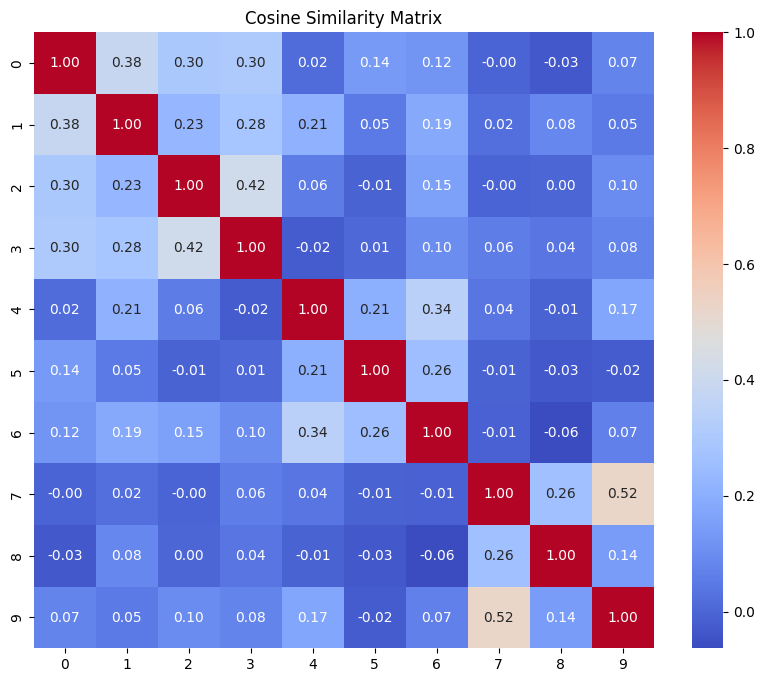

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [8]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

In [9]:
top_indices = scores.argsort()[-2:][::-1]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", round(scores[idx], 4))
    print()

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

Sentence: The bowler delivered a fast yorker
Similarity Score: 0.5414

